# Disaster Tweet Classification: Day-3: Baseline Model

## Goal
Build the first reproducible baseline model for classifying disaster tweets.

## What this notebook does
1. Load the training data
2. Recreate the text preprocessing pipeline
3. Split the data into train and validation sets
4. Build a baseline TF-IDF + Multinomial Naive Bayes pipeline
5. Evaluate with F1, precision, recall, accuracy, and confusion matrix
6. Save the confusion matrix figure

## Important rule
TF-IDF must be fit on `X_train` only, never on the full dataset.
That prevents validation leakage.

In [10]:
print("Imports and Constants")

import os
import re
import warnings
from IPython.display import display

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.2
MAX_FEATURES = 10000
NGRAM_RANGE = (1, 1)
ALPHA = 1.0
MIN_TOKEN_LENGTH = 2

TRAIN_PATH = "../data/train.csv"
TRAIN_PREPROCESSED_PATH = "../outputs/train_processed.csv"
FIGURES_DIR = "../outputs/figures"

os.makedirs(FIGURES_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 250)

Imports and Constants


## NLTK setup

The baseline model uses the same cleaning logic as Day 2 so that preprocessing remains consistent across notebooks.

In [2]:
print("NLTK Downloads")

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

NLTK Downloads


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kaust\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kaust\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kaust\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\kaust\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\kaust\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [18]:
print("Load Data")

df = pd.read_csv(TRAIN_PREPROCESSED_PATH)

df["cleaned_text"] = df["cleaned_text"].fillna("").astype(str)
df["cleaned_text"] = df["cleaned_text"].str.strip()

print(f"Shape: {df.shape}")
display(df.head())

print("Missing cleaned_text:", df["cleaned_text"].isna().sum())
print("Empty cleaned_text:", (df["cleaned_text"].fillna("").str.len() == 0).sum())

display(df[["text", "cleaned_text", "target"]].head())

Load Data
Shape: (7613, 13)


,id,keyword,location,text,target,hashtags,has_hashtag,cleaned_text,raw_char_count,cleaned_char_count,raw_word_count,cleaned_word_count,keyword_decoded
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1,['earthquake'],True,deed reason earthquake may allah forgive,69,40,13,6,NaN
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1,[],False,forest fire near la ronge sask canada,38,37,7,7,NaN
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,1,[],False,resident asked shelter place notified officer evacuation shelter place order expected,133,85,22,11,NaN
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1,['wildfires'],True,people receive wildfire evacuation order california,65,51,8,6,NaN
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1,"['alaska', 'wildfires']",True,got sent photo ruby alaska smoke wildfire pours school,88,54,16,9,NaN


Missing cleaned_text: 0
Empty cleaned_text: 2


,text,cleaned_text,target
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,deed reason earthquake may allah forgive,1
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,1
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,resident asked shelter place notified officer evacuation shelter place order expected,1
3,"13,000 people receive #wildfires evacuation orders in California",people receive wildfire evacuation order california,1
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,got sent photo ruby alaska smoke wildfire pours school,1


## Train-validation split

I split before vectorization so the TF-IDF vocabulary is learned only from training data.

This is critical because fitting TF-IDF on the full dataset would leak validation information into the model and inflate performance.

In [19]:
print("Split Data")

X = df['cleaned_text']
y = df['target']

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,     #  parameter ensures that the training and testing datasets maintain the exact same proportion of class labels as the original dataset
    random_state=RANDOM_STATE
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")

print("y_train distribution")
print(y_train.value_counts(normalize=True).round(4))

print("y_val distribution")
print(y_val.value_counts(normalize=True).round(4))

Split Data
X_train shape: (6090,)
X_val shape: (1523,)
y_train shape: (6090,)
y_val shape: (1523,)
y_train distribution
target
0    0.5703
1    0.4297
Name: proportion, dtype: float64
y_val distribution
target
0    0.5706
1    0.4294
Name: proportion, dtype: float64


## Majority-class sanity baseline

Before training a real model, it helps to remember how weak a naive classifier would be here.

If a model always predicts `0` (not disaster), it will get decent-looking accuracy because the dataset is mildly imbalanced, but its F1 score for the positive class will be terrible.

In [20]:
print("Majority-class Baseline")

majority_pred = np.zeros_like(y_val)

majority_metrics = {
    "model": "Majority Class Baseline",
    "f1": f1_score(y_val, majority_pred, zero_division=0),
    "precision": precision_score(y_val, majority_pred, zero_division=0),
    "recall": recall_score(y_val, majority_pred, zero_division=0),
    "accuracy": accuracy_score(y_val, majority_pred)
}

pd.DataFrame([majority_metrics]).round(4)

Majority-class Baseline


,model,f1,precision,recall,accuracy
0,Majority Class Baseline,0.0,0.0,0.0,0.5706


## Experiment 001: TF-IDF + Multinomial Naive Bayes

This is the official baseline model from the project plan.

Why this baseline:
- TF-IDF works well for short sparse text
- Naive Bayes is fast, simple, and strong enough to establish a useful benchmark

In [21]:
print("Build Pipeline")

baseline_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(      # Convert text to numbers
        ngram_range=NGRAM_RANGE,    # Unigrams
        max_features=MAX_FEATURES   # Top words/features
    )),
    ("clf", MultinomialNB(alpha=ALPHA))     # Multinomial Naive Bayes model for text classification
])

baseline_pipeline

Build Pipeline


Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=10000)),
                ('clf', MultinomialNB())])

In [22]:
print("fit Baseline Model")

baseline_pipeline.fit(X_train, y_train)

print("Baseline model fitted successfully.")

fit Baseline Model
Baseline model fitted successfully.


In [23]:
print("Prediction on Validation Set")

y_val_pred = baseline_pipeline.predict(X_val)

print("Predictions generated.")

Prediction on Validation Set
Predictions generated.


In [24]:
print("Evaluation Metrics")

baseline_results = {
    "model": "MultinomialNB + TF-IDF (1,1)",
    "f1": f1_score(y_val, y_val_pred),
    "precision": precision_score(y_val, y_val_pred),
    "recall": recall_score(y_val, y_val_pred),
    "accuracy": accuracy_score(y_val, y_val_pred)
}

results_df = pd.DataFrame([majority_metrics, baseline_results]).round(4)
display(results_df)

Evaluation Metrics


,model,f1,precision,recall,accuracy
0,Majority Class Baseline,0.0000,0.000,0.0000,0.5706
1,"MultinomialNB + TF-IDF (1,1)",0.7732,0.854,0.7064,0.8221


In [25]:
print("Classification Report")

print(classification_report(y_val, y_val_pred, digits=4))

Classification Report
              precision    recall  f1-score   support

           0     0.8045    0.9091    0.8536       869
           1     0.8540    0.7064    0.7732       654

    accuracy                         0.8221      1523
   macro avg     0.8292    0.8078    0.8134      1523
weighted avg     0.8257    0.8221    0.8191      1523



Confusion Matrix


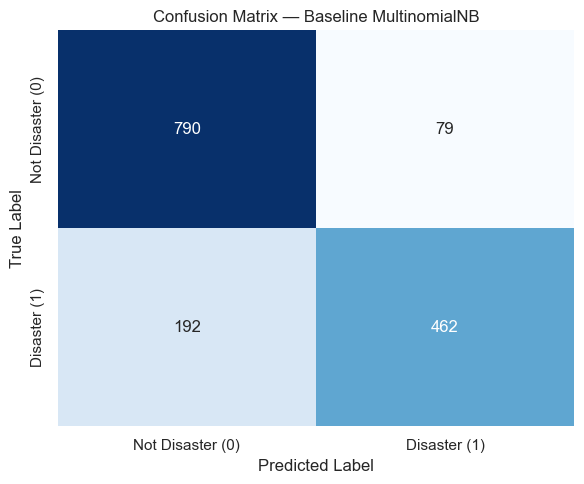

In [26]:
print("Confusion Matrix")

cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Not Disaster (0)", "Disaster (1)"],
    yticklabels=["Not Disaster (0)", "Disaster (1)"]
)
plt.title("Confusion Matrix — Baseline MultinomialNB")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Inspect a few validation predictions

Metrics give the summary, but example predictions help build intuition.

At this stage, I only want a quick look at which tweets are being classified correctly or incorrectly. Full error analysis comes later.

In [27]:
print("Validation Prediction Table")

val_results_df = pd.DataFrame({
    "text": X_val.values,
    "true_label": y_val.values,
    "pred_label": y_val_pred
})

val_results_df["correct"] = val_results_df["true_label"] == val_results_df["pred_label"]

display(val_results_df.sample(15, random_state=RANDOM_STATE))

Validation Prediction Table


,text,true_label,pred_label,correct
566,deadpool already one favourite marvel character know wear red suit bad guy tell bleeding,0,0,True
1101,rt homeless vulnerable north texas heat wave,1,1,True
1475,would great mbiwa flattened little rat,0,0,True
1178,fascinating pic inside north korea propaganda devastation people living life,0,1,False
1009,hollywood movie trapped miner released chile zippednews,0,0,True
433,da one mtvsummerstar videoveranomtv mtvhottest britney spear lana del rey,0,0,True
855,building fire time business meeting thestrain,1,0,False
1493,heat advisory effect pm pm thursday building heat wave increasing humidity lawx,1,1,True
1032,burst actual tear joy cain survived summerfate,0,0,True
1079,dating someone let smoke leave date someone also smoke trust,0,0,True


In [28]:
print("False Positives and False Negatives Review")

false_positives = val_results_df[
    (val_results_df["true_label"] == 0) & (val_results_df["pred_label"] == 1)
].copy()

false_negatives = val_results_df[
    (val_results_df["true_label"] == 1) & (val_results_df["pred_label"] == 0)
].copy()

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

print("\nSample false positives:")
display(false_positives.head(10))

print("\nSample false negatives:")
display(false_negatives.head(10))

False Positives and False Negatives Review
False positives: 79
False negatives: 192

Sample false positives:


,text,true_label,pred_label,correct
14,firefighter acted like cop drive around shooting flamethrower burning building,0,1,False
19,get pic show trophy outbreak photoshop,0,1,False
34,slicker oil spill,0,1,False
58,article michael jackman metro time detroit group later downgraded estimate square mile,0,1,False
86,sismo km nne geyser california time utc,0,1,False
88,drowning actavis suicide,0,1,False
125,since biggest depreciation cad usd yr federal election coincide landslide win opposition,0,1,False
158,governor weighs parole california school bus hijacker,0,1,False
178,mercury cyclone gt hood moulding nice core cobra jet cj gt,0,1,False
188,today fell rock scraped whole butt nearly drowned summer,0,1,False



Sample false negatives:


,text,true_label,pred_label,correct
5,hollywood movie trapped miner released chile hollywood movie trapped miner starring,1,0,False
7,drown demon know swim,1,0,False
13,need plant pacific cyclone season would help,1,0,False
16,look like mudslide poor thing greatbritishbakeoff,1,0,False
22,flip side walmart bomb everyone evacuate stay tuned blow,1,0,False
26,bomb head explosive decision dat produced dead child dead body trapped tween building day september,1,0,False
27,agree certain cultural appropriation thing honestly looked house scream appropriation bc buddha stuff,1,0,False
29,dress meme officially exploded internet,1,0,False
30,aquarium ornament wreck sailing boat sunk ship destroyer fish tank cave decor full read,1,0,False
35,maybe happens tornado meet volcano,1,0,False


In [29]:
print("Most important learned feature(s)")

tfidf = baseline_pipeline.named_steps["tfidf"]
clf = baseline_pipeline.named_steps["clf"]

feature_names = np.array(tfidf.get_feature_names_out())
log_probs = clf.feature_log_prob_

top_not_disaster = pd.DataFrame({
    "feature": feature_names[np.argsort(log_probs[0])[::-1][:20]],
    "log_prob": np.sort(log_probs[0])[::-1][:20]
})

top_disaster = pd.DataFrame({
    "feature": feature_names[np.argsort(log_probs[1])[::-1][:20]],
    "log_prob": np.sort(log_probs[1])[::-1][:20]
})

print("Top features for Not Disaster (0)")
display(top_not_disaster)

print("Top features for Disaster (1)")
display(top_disaster)

Most important learned feature(s)
Top features for Not Disaster (0)


,feature,log_prob
0,like,-6.079532
1,get,-6.241873
2,new,-6.412402
3,one,-6.586564
4,love,-6.638332
5,body,-6.677077
6,day,-6.740152
7,would,-6.782051
8,got,-6.801157
9,let,-6.804844


Top features for Disaster (1)


,feature,log_prob
0,fire,-5.953938
1,news,-6.505979
2,california,-6.548997
3,hiroshima,-6.622248
4,disaster,-6.630284
5,via,-6.652659
6,suicide,-6.655824
7,year,-6.666628
8,building,-6.709483
9,police,-6.717482


In [31]:
print(f"F1 score (val):  {baseline_results['f1']:.4f}")
print(f"Precision (val): {baseline_results['precision']:.4f}")
print(f"Recall (val):    {baseline_results['recall']:.4f}")
print(f"Accuracy (val):  {baseline_results['accuracy']:.4f}")

F1 score (val):  0.7732
Precision (val): 0.8540
Recall (val):    0.7064
Accuracy (val):  0.8221


## Day 3 Observations

### 1. Baseline performance
- The baseline `MultinomialNB + TF-IDF (1,1)` model achieved **F1 = 0.7732**, **precision = 0.8540**, **recall = 0.7064**, and **accuracy = 0.8221** on the validation set.
- This is a strong improvement over the majority-class baseline, which had 57.06% accuracy but 0 F1 for the disaster class.
- That confirms the cleaned text contains meaningful predictive signal and that the preprocessing pipeline is working.

### 2. Precision vs recall tradeoff
- The model currently has higher precision than recall.
- This means it is relatively careful when predicting disaster tweets, but it still misses many real disaster examples.
- The confusion matrix supports this: there are **79 false positives** and **192 false negatives**.

### 3. What the model seems to learn
- The most important disaster-associated words include `fire`, `news`, `california`, `hiroshima`, `disaster`, `suicide`, `building`, `storm`, `killed`, and `bomb`.
- The most important non-disaster words include generic conversational words such as `like`, `get`, `new`, `one`, `love`, `day`, `want`, `go`, and `time`.
- This suggests the baseline model is relying mainly on unigram-level lexical cues rather than deeper context.

### 4. Error pattern hints
- Several false positives contain strong disaster vocabulary in non-disaster contexts, which is expected for a unigram Naive Bayes model.
- Several false negatives appear to involve ambiguous phrasing, short context, or wording that may require more phrase-level understanding.
- This suggests that the next improvement should focus on a more expressive classifier and richer n-gram features.

### 5. Next step
- The next experiment should be **Logistic Regression with unigram TF-IDF**.
- After that, the most important upgrade will likely be **TF-IDF with bigrams**, because disaster meaning often depends on short phrases rather than isolated words.